#Diabetes Risk Factor Analysis - Week 2 Reproducibility Exercise

**Author:** Katerina Smith

# Purpose and Overview

This notebook provides an exploratory statistical analysis of a diabetes risk-factor dataset, which was collected from a cohort of female patients. It was originally developed for internal review but has now  been reorganized into a reproducible workflow so that a data science team at another clinical site has the ability to execute it independently and obtain the same results.

With this notebook, a data science team will be able to:

* Load and validate the dataset.
* Summarize descriptive statistics.
* Visualize individual variables and the relationship between variables.
* Test whether two clinical measurements (glucose and BMI) differ significantly between patients with and without diabetes.

How to use this notebook: run every cell from top to bottom, in order, or alternatively "Run All". A description of each step is provided as a markdown cell in each step, along with instructions on how to interpret each output.

# Setup and Environment

This analysis uses the following Python libraries:

| Library | Purpose | Version |
|---|---|---|
| pandas | Loading and manipulating tabular data | 2.x |
| numpy | Numerical operations | 1.2x |
| scipy | Statistical tests (t-test, Mann-Whitney U) | 1.1x |
| matplotlib | Plotting | 3.x |
| seaborn | Statistical visualizations (heatmap) | 0.13.x |


If you are running this in Google Colab, all of these libraries are
pre-installed, so installing these libraries is not necessary.

If you are running this outside Colab, uncomment and run the pip install line in the cell below once, before running the rest of the notebook.

A fixed random seed is set below and reused everywhere randomness
occurs, so that every execution of this notebook will produce the same results.


In [1]:
#Uncomment the line below if a required library is not already installed
#(not necessary in Google Colab, where these libraries are pre-installed).
#%pip install -q pandas numpy scipy matplotlib seaborn

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

#Fixed seed so every run of this notebook produces identical results
RANDOM_SEED = 42

#Print the versions running in this session
print(f"Python:     {sys.version.split()[0]}")
print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn:    {sns.__version__}")


Python:     3.13.15
pandas:     2.2.3
numpy:      2.1.3
matplotlib: 3.10.0
seaborn:    0.13.2


## Dataset Source and Provenance

**Dataset:** Pima Indians Diabetes Dataset (provided for this course as
Example_Dataset_Diabetes.csv).

**Original source:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK), distributed via the UCI Machine Learning Repository /
Kaggle. The version used in this notebook has been provided by the course as a teaching dataset.

**Population:** 768 female patients of Pima Indian heritage, age 21 and older.

**Columns:**

| Column | Description |
|---|---|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration (2-hour oral glucose tolerance test), mg/dL |
| D_BP | Diastolic blood pressure, mm Hg |
| Skin_Thickness | Triceps skinfold thickness, mm |
| Insulin | 2-hour serum insulin, mu U/mL |
| BMI | Body mass index, kg/m² |
| Pedigree | Diabetes pedigree function (a score estimating diabetes likelihood from family history) |
| Age | Age in years |
| Outcome | Target variable: 1 = diabetes, 0 = no diabetes |

**Known data-quality caveat:** in this dataset, missing measurements for Glucose, D_BP, Skin_Thickness, Insulin, and BMI appear to have been encoded as 0 rather than as a true missing value (a value of 0 mm Hg blood pressure or 0 mg/dL glucose is not physiologically possible in a
living patient). This notebook documents this pattern in the Data Validation and Data Preparation sections below.

**Redistribution:** this dataset is included directly in this project's GitHub repository (Example_Dataset_Diabetes.csv).

## Data Loading

The cell below loads the dataset using a two-step, approach so it works for any user, in any environment, without needing to edit the code:

1. If the CSV file is present in the current working directory, it is loaded directly from disk.
2. If it is not present in the current working directory, it is retrieved directly from this project's GitHub repository.


In [2]:
import os

LOCAL_PATH = "Example_Dataset_Diabetes.csv"

DATA_URL = "https://raw.githubusercontent.com/katerina-smith/Programming_for_HDS_Week2/refs/heads/main/Example_Dataset_Diabetes.csv"

#if file is available in local directory
if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print(f"Loaded dataset from local file: {LOCAL_PATH}")
#otherwise retrieve from Github URL
else:
    df = pd.read_csv(DATA_URL)
    print(f"Loaded dataset from remote URL: {DATA_URL}")

df.head()


Loaded dataset from remote URL: https://raw.githubusercontent.com/katerina-smith/Programming_for_HDS_Week2/refs/heads/main/Example_Dataset_Diabetes.csv


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Validation

Before proceeding with any analysis, we confirm that the dataset that was actually loaded matches what this notebook expects regarding the right shape, the right columns, and proper numeric format.

In [3]:
def validate_dataset(frame: pd.DataFrame, expected_columns: set, min_rows: int = 1) -> None:
    """Raise a clear error if the loaded dataset doesn't match expectations.
    """
    missing_columns = expected_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f"Dataset is missing expected column(s): {missing_columns}")
    if len(frame) < min_rows:
        raise ValueError(f"Dataset has only {len(frame)} row(s); expected at least {min_rows}.")
    non_numeric = [c for c in expected_columns if not pd.api.types.is_numeric_dtype(frame[c])]
    if non_numeric:
        raise ValueError(f"Expected numeric column(s) are not numeric: {non_numeric}")


EXPECTED_COLUMNS = {
    "Pregnancies", "Glucose", "D_BP", "Skin_Thickness", "Insulin",
    "BMI", "Pedigree", "Age", "Outcome",
}

validate_dataset(df, EXPECTED_COLUMNS, min_rows=1)

print(f"Validation passed: {df.shape[0]} rows, {df.shape[1]} columns.")
print("\nColumn data types:")
print(df.dtypes)
print("\nCount of NaN values per column (see note below):")
print(df.isna().sum())
print("\nCount of zero values in columns where 0 is not physiologically plausible:")
implausible_zero_columns = ["Glucose", "D_BP", "Skin_Thickness", "Insulin", "BMI"]
print((df[implausible_zero_columns] == 0).sum())


Validation passed: 768 rows, 9 columns.

Column data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object

Count of NaN values per column (see note below):
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Count of zero values in columns where 0 is not physiologically plausible:
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
dtype: int64


**How to interpret this output:** the .isna() check above will show 0 missing
values in every column. As noted in Data Source and Provenance, missing measurements in this dataset were encoded as 0 rather than as a true missing value, so .isna() cannot detect them. The zero-count check above shows how common this is. This is a caveat of this dataset and any data scientist who uses this workflow should treat these zeros as likely missing data, not as valid clinical measurements.


## Data Preparation

**Duplicate records:** None were found in this dataset.

**Decision on the zero-encoded missing values described above:** this notebook intentionally does not impute or drop these values. The purpose of this exercise is to demonstrate a transparent, reproducible workflow structure but still preserve the notebook's original analytical results.


In [4]:
n_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {n_duplicates}")


Exact duplicate rows: 0


## Analysis


### Descriptive Statistics

The table below reports summary statistics, such as count, mean, standard
deviation, min/max, and quartiles.


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
D_BP,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
Skin_Thickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
Pedigree,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


\
**Mean and standard deviation**

The mean is the average value of a measurement across all patients in the
dataset:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

where $\bar{x}$ is the sample mean, $x_i$ is the value of the measurement for patient $i$, and $n$ is the number of patients ($n = 768$ in this dataset).

The standard deviation measures how spread out those values are around the mean:

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

**Dataset application:** average Glucose across all 768 patients is 120.89 mg/dL with a standard deviation of 31.97. This suggests glucose readings vary across this patient population. BMI has a mean of 31.99
kg/m² with a standard deviation of 7.88, which suggests that BMI is comparatively more consistent across patients than
glucose.


### Univariate Visualizations

The two histograms below show the distribution of Glucose and BMI across all patients. Both visualizations are plotted using one reusable
function (plot_histogram).


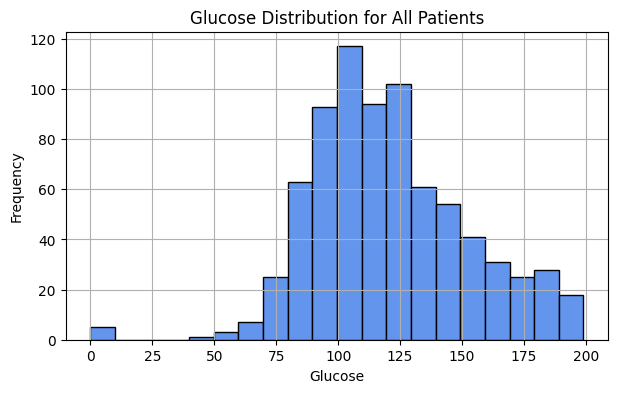

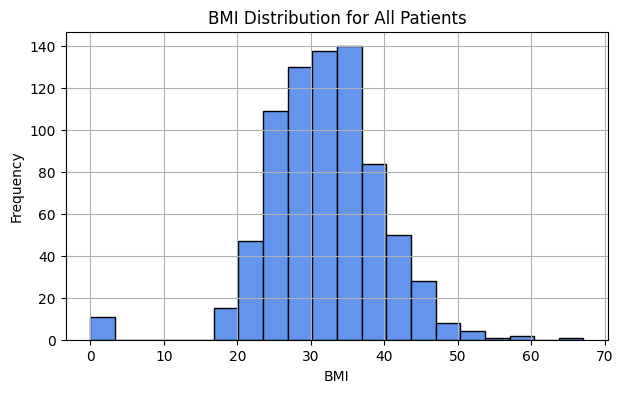

In [6]:
def plot_histogram(frame: pd.DataFrame, column: str, title: str, color: str = "cornflowerblue") -> None:
    """Plot a labeled histogram for one numeric column."""
    plt.figure(figsize=(7, 4))
    frame[column].hist(bins=20, color=color, edgecolor="black")
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


plot_histogram(df, "Glucose", "Glucose Distribution for All Patients")
plot_histogram(df, "BMI", "BMI Distribution for All Patients")


**Interpretation:** the Glucose distribution is right-skewed with a small cluster of implausible 0 values; ignoring that cluster, most patients fall between roughly 90-140 mg/dL. The BMI distribution is bell-shaped and centered in the low-30s, which is consistent with an overweight population, again with a similar small cluster of implausible 0 values.

### Bivariate Visualizations

The visualizations above describe one variable at a time. The two visualizations below examine the relationships between variables. Specifically, the examine how a patient characteristic relates to their diabetes status, and also how two continuous measurements relate to each other.


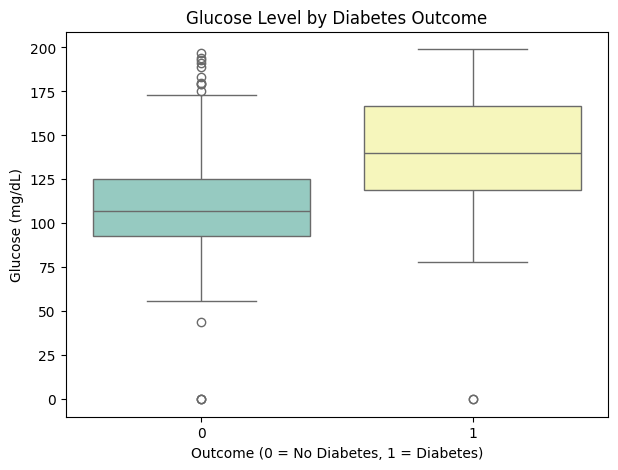

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Outcome", y="Glucose", hue="Outcome", palette="Set3", legend=False)
plt.title("Glucose Level by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Glucose (mg/dL)")
plt.show()


**Interpretation:** this visual shows that patients with diabetes have a visibly higher median glucose level and a distribution shifted upward, compared to patients without diabetes.

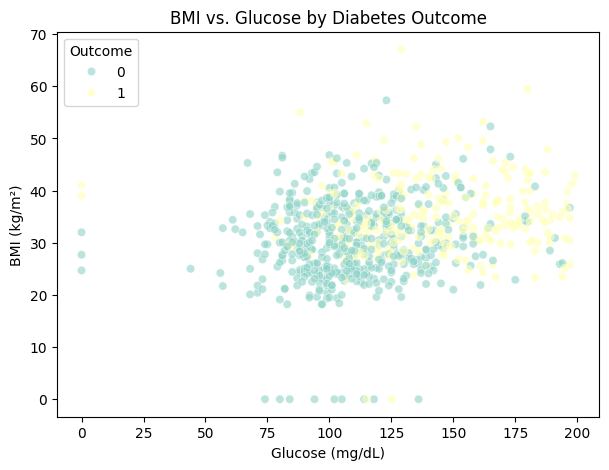

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome", palette="Set3", alpha=0.6)
plt.title("BMI vs. Glucose by Diabetes Outcome")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI (kg/m²)")
plt.legend(title="Outcome")
plt.show()


**Interpretation:** this visual shows that there is a weak positive relationship between Glucose and BMI overall. Patients with diabetes appear to be concentrated toward the higher end of both measurements rather than spread evenly across the plot.


### Correlation Matrix

**Method choice:** this dataset contains several skewed, zero-inflated variables, such as Insulin and Skin_Thickness, which is a violation of the linearity and normality assumptions of the Pearson correlation. Therefore, we use Spearman's rank correlation since it only requires a monotonic relationship between variables.

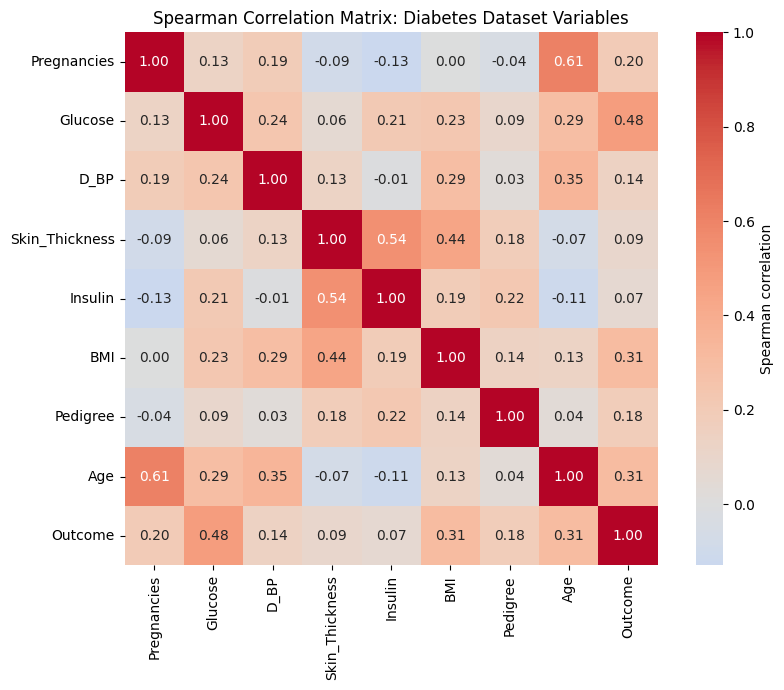

In [9]:
correlation_matrix = df.corr(method="spearman").round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, cbar_kws={"label": "Spearman correlation"})
plt.title("Spearman Correlation Matrix: Diabetes Dataset Variables")
plt.tight_layout()
plt.show()

**Interpretation:** This visual shows that glucose has the strongest relationship with Outcome (ρ = 0.48), followed by BMI (ρ = 0.31), and then Age (ρ = 0.31). Insulin and Skin_Thickness are the most strongly correlated pair among the predictors themselves (ρ = 0.54). It is important to keep in mind that given that both variables have a large number of zero-encoded values, part of this correlation might be a reflection of patients missing both measurements together, and should be interpreted cautiously. Lastly, these relationships describe statistical association and do not establish causation.

### Inferential Analysis

**Test 1: Independent-samples t-test; Glucose by diabetes outcome**

**Purpose:** the purpose of this test is to test whether the average glucose level differs between patients with and without diabetes.

**Method:** Welch's two-sample t-test compares the means of two
independent groups:

$$
t = \frac{\bar{x}_1 - \bar{x}_0}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_0^2}{n_0}}}
$$

where $\bar{x}_1$ and $\bar{x}_0$ are the mean glucose values for the diabetic and non-diabetic groups, $s_1^2$ and $s_0^2$ are their variances, and $n_1$, $n_0$ are the group sizes.


In [10]:
group_no_diabetes = df.loc[df["Outcome"] == 0, "Glucose"]
group_diabetes = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(group_no_diabetes, group_diabetes)

print(f"Mean Glucose (No Diabetes, n={len(group_no_diabetes)}): {group_no_diabetes.mean():.2f}")
print(f"Mean Glucose (Diabetes, n={len(group_diabetes)}):    {group_diabetes.mean():.2f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.3e}")


Mean Glucose (No Diabetes, n=500): 109.98
Mean Glucose (Diabetes, n=268):    141.26
t-statistic: -14.600
p-value:     8.935e-43


**Result and interpretation:** mean glucose is 109.98 mg/dL in patients without diabetes versus 141.26 mg/dL in patients with diabetes. This is a highly statistically significant difference (t ≈ -14.6, p < 0.001). This is to be expected, as glucose tolerance is directly related to diabetes diagnosis.


**Test 2: Mann-Whitney U test; BMI by diabetes outcome**

**Purpose:** the t-test above assumes the two groups' data are approximately normally distributed. BMI includes zero-encoded values and is somewhat skewed, therefore we use a second non-parametric test that does not require this assumption, in order to check whether we come to the same conclusion.

**Method:** the Mann-Whitney U test compares the rank distributions of two independent groups rather than their means:

$$
U_1 = n_1 n_0 + \frac{n_1(n_1+1)}{2} - R_1
$$

where $n_1$ and $n_0$ are the two group sizes and $R_1$ is the sum of the ranks assigned to group 1.

In [11]:
bmi_no_diabetes = df.loc[df["Outcome"] == 0, "BMI"]
bmi_diabetes = df.loc[df["Outcome"] == 1, "BMI"]

u_stat, p_value_u = mannwhitneyu(bmi_no_diabetes, bmi_diabetes, alternative="two-sided")

print(f"Median BMI (No Diabetes): {bmi_no_diabetes.median():.2f}")
print(f"Median BMI (Diabetes):    {bmi_diabetes.median():.2f}")
print(f"U-statistic: {u_stat:.1f}")
print(f"p-value:     {p_value_u:.3e}")

Median BMI (No Diabetes): 30.05
Median BMI (Diabetes):    34.25
U-statistic: 41866.0
p-value:     9.731e-18


**Result and interpretation:** the median BMI is 30.05 kg/m² in patients without diabetes versus 34.25 kg/m² in patients with diabetes. This is in agreement with the correlation observed above (BMI's positive association with Outcome). Because this test does not assume normally distributed data, it gives us more confidence that the BMI difference
between groups is real.


### Reproducibility Check

The two cells below draw a random sample and compute a bootstrap resampled estimate. These are used here only to verify that this notebook produces identical output every time it is executed.


In [12]:
#A small random sample of patients with a seed for reproducibility.
df.sample(8, random_state=RANDOM_SEED)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0
204,6,103,72,32,190,37.7,0.324,55,0
97,1,71,48,18,76,20.4,0.323,22,0
336,0,117,0,0,0,33.8,0.932,44,0


In [13]:
#A single bootstrap resampled estimate of mean BMI with a seed for reproducibility.
bootstrap_mean_bmi = df["BMI"].sample(n=len(df), replace=True, random_state=RANDOM_SEED).mean()
print(f"Bootstrap-resampled mean BMI: {bootstrap_mean_bmi:.2f}")

Bootstrap-resampled mean BMI: 31.93


## Results

- The dataset contains 768 patients: 500 without diabetes (65.1%) and 268 with diabetes (34.9%).
- **Glucose** is the single measurement most strongly associated with diabetes status in this dataset. Also, its mean differs significantly between groups (109.98 mg/dL vs. 141.26 mg/dL; t-test p < 0.001).
- **BMI** is associated with diabetes status (ρ = 0.31), having a
  significantly higher median in the diabetic group (34.25 vs. 30.05 kg/m²).
- **Age** shows a similar strength association with Outcome (ρ = 0.31) as BMI.
- **Insulin** and **Skin_Thickness** are the most correlated pair among the predictor variables themselves (ρ = 0.54), but this may be partly due to the fact that both variables share many zero-encoded values in the same patients.
- No duplicate records were found in the dataset.

## Conclusions

This analysis found that glucose level and BMI are associated with diabetes status in this patient population. Age also showed a similar
association. These findings are consistent with clinical knowledge about the factors that are associated wit the risk of developing diabetes.

**Assumptions and limitations:**
- **Missing data encoded as zero.** Glucose, D_BP, Skin_Thickness, Insulin, and BMI, all contain physiologically implausible zero values that likely represent missingness. This notebook does not impute or remove them; all descriptive statistics, tests, and correlations conducted include these zero values.
- **Cross-sectional, observational data.** All relationships reported here are associations and do not establish causality.
- **Single population.** This dataset reflects one specific patient population.

A data scientist at another clinical site should be able to run this notebook  by selecting **Runtime → Restart session and run all** in Colab, using only the
dataset included in this repository. The figures and statistics obtained should match the results reported above.